# Trades File Acceptance Audit

Notebook file-level de fase 2 para validar `trades` con patrón low-memory.   
No carga el full en memoria: consume artefactos peque?os construidos offline por el builder de aceptación.

Este notebook está hecho para:

- definir bien la auditoría file-level
- comprobar que las métricas correctas tienen sentido
- ver cómo se comportan los distintos tipos de casos
- afinar la lógica good / review / bad
- y granular el problema antes de escalarlo

No está hecho todavía para certificar el 100% raw file-by-file.

Ahora mismo sirve como:

- notebook de diseño operativo de la auditoría profunda
- notebook de validación metodológica sobre muestra estratificada
- paso previo al builder full definitivo

La secuencia correcta es:

1. usar este notebook para revisar si las capas y métricas están bien planteadas
2. corregir lo que no convenza
3. cerrar la política de aceptación
4. entonces construir el builder 100% raw para todo el universo

## Contexto

Este notebook se apoya en el trabajo previo de `fase1` y en la materializaci?n `C + D`, pero cambia el objetivo: ya no busca solo caracterizar el residuo global, sino decidir si un file puede darse por bueno, revisable o malo a nivel operativo.

In [1]:
import runpy
from pathlib import Path
from IPython.display import Markdown, display

SCRIPT_58B = Path(
    r"C:/TSIS_Data/02_backtest_SmallCaps/data_auditoria_polygon/00_data_certification/auditoria/trades/cell_code/58b_trades_file_acceptance_view_lt1b.py"
)

mod58b = runpy.run_path(str(SCRIPT_58B))
manifest = mod58b["load_manifest"]()
arts = mod58b["load_all_artifacts"]()
mod58b["show_manifest"](manifest)


**files_total:** 9,429,112  
**sample_files:** 380  
**current parquet:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\trades_current.parquet`  
**cache dir:** `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\trades_v2_materialized\trades_current_cd_merged\root_cause_exports\file_acceptance_cache_lt1b`  
**built_at_utc:** `2026-04-19T19:45:39.889506+00:00`  
**batch_size:** `50000`  
**sample_per_stratum:** `20`

## Primera capa

**Integridad del file**. Esta capa responde a una pregunta binaria: el file es f?sicamente utilizable o no lo es.

No hay ejemplos de `layer1_integrity_examples` para previsualizar files.

,metric,value
0,files_total,9429112
2,soft_fail_files,5241738
3,hard_fail_files,3643437
1,pass_files,543937
5,files_dtype_mismatch,23691
4,files_missing_required_cols,0
6,files_negative_price,0
7,files_negative_size,0
8,files_timestamp_out_of_partition,0
9,files_empty_after_parse,0


En esta capa cada métrica responde a una pregunta física sobre el file.  
`files_total`: número total de files evaluados en la capa de integridad.  
`files_missing_required_cols`: files a los que les faltan columnas obligatorias del schema esperado.  
`files_dtype_mismatch`: files donde el tipo de una o más columnas no coincide con el contrato esperado.  
`files_negative_price`: files con al menos un trade con `price < 0`; eso sí es físicamente inválido.  
`files_negative_size`: files con al menos un trade con `size < 0`; eso sí rompe la validez del volumen negociado.  
`files_timestamp_out_of_partition`: files con trades cuyo timestamp cae fuera del día de la partición.  
`files_empty_after_parse`: files que existen pero quedan vacíos tras parseo, limpieza o normalización.  
`files_zero_raw_rows`: files físicamente presentes pero sin filas útiles ya desde la lectura raw.

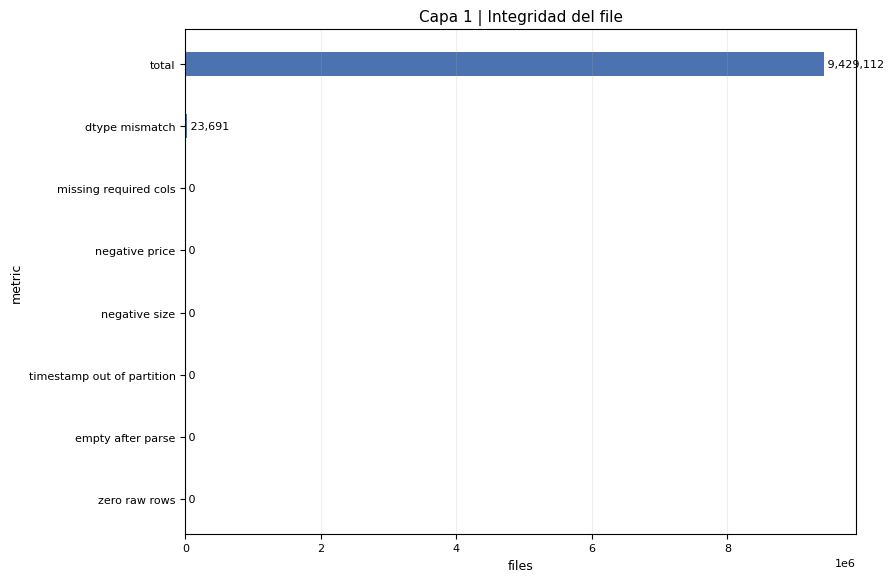

La primera capa verifica si el file es físicamente utilizable. Sobre 9,429,112 files, la masa con fallos duros de integridad es 23,691. Si este bloque fuese grande, el dataset quedaría invalidado antes de entrar en microestructura.

In [2]:
layer1 = arts['layer1_integrity_summary']
layer1_examples = arts['layer1_integrity_examples']
layer1_example_idx = 0
layer1_example_rows = 5
layer1_plot_max_metrics = 8
mod58b['show_layer1_file_example'](layer1_examples, example_idx=layer1_example_idx, n_rows=layer1_example_rows)
mod58b['display_table'](layer1, 'layer1_integrity_summary', sort_by=['value'], ascending=False, default_rows=30)
display(Markdown(mod58b['explain_layer1_metrics'](layer1)))
mod58b['plot_layer1_integrity'](layer1, max_metrics=layer1_plot_max_metrics)
display(Markdown(mod58b['summary_layer1'](layer1)))


**negative_price**

In [3]:
display(Markdown("**Nota**: la celda antigua de `59_layer1_zero_negative_split.py` queda fuera del flujo principal `<1B>` de este notebook. Si se quiere recuperar, debe rehacerse consumiendo artefactos `<1B>` ya materializados."))

**Nota**: la celda antigua de `59_layer1_zero_negative_split.py` queda fuera del flujo principal `<1B>` de este notebook. Si se quiere recuperar, debe rehacerse consumiendo artefactos `<1B>` ya materializados.

Resumen breve de hallazgos de la primera capa: si aqu? apareciera una masa grande de files rotos, no tendr?a sentido seguir. Si esta capa queda acotada, la discusi?n real pasa a elegibilidad y consistencia microestructural.

## Segunda capa

**Perfil descriptivo del tape**. Antes de fijar elegibilidad hay que mirar qu? prints hay realmente en la muestra: sesi?n, `conditions`, disponibilidad de referencias y qu? casos ya vienen marcados con off-session.

,metric,value
0,sample_files,380.000000
1,median_regular_trade_pct,100.000000
2,median_prepost_trade_pct,0.000000
3,median_baseline_eligible_trade_pct,100.000000
4,files_with_1m_reference_pct,87.631579
5,files_with_daily_reference_pct,99.736842


,metric,value
0,median_premarket_trade_pct,0.000000
1,median_regular_trade_pct_raw,100.000000
2,median_afterhours_trade_pct,0.000000
3,median_off_session_trade_pct_raw,0.000000
4,files_with_off_session_gt_0_pct_raw,0.000000
5,median_odd_lot_trade_pct,53.939667
6,median_round_lot_trade_pct,46.060333
7,median_outside_daily_premarket_pct,NaN
8,median_outside_daily_regular_pct,3.117716
9,median_outside_daily_afterhours_pct,NaN


,metric,value
0,sample_files,380.000000
1,files_with_off_session_pct_gt_0,30.789474
2,median_off_session_trade_pct,0.000000
3,median_positive_off_session_trade_pct,23.296351
4,files_with_1m_reference_pct_sample_index,87.631579
5,files_with_daily_reference_pct_sample_index,99.736842
6,median_condition_combo_nunique,6.000000
7,p95_condition_combo_nunique,11.000000


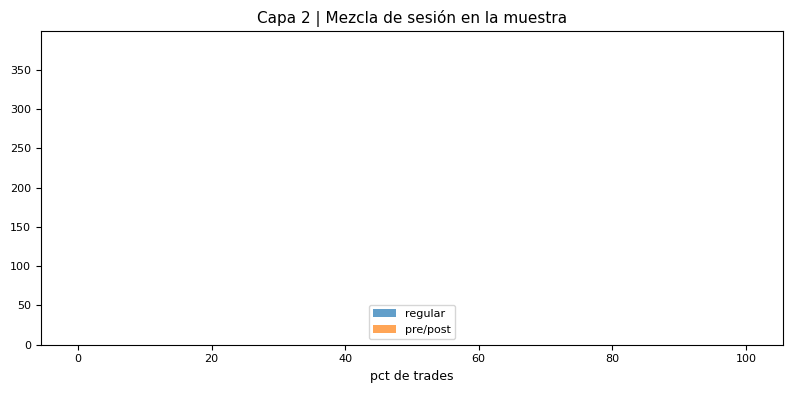

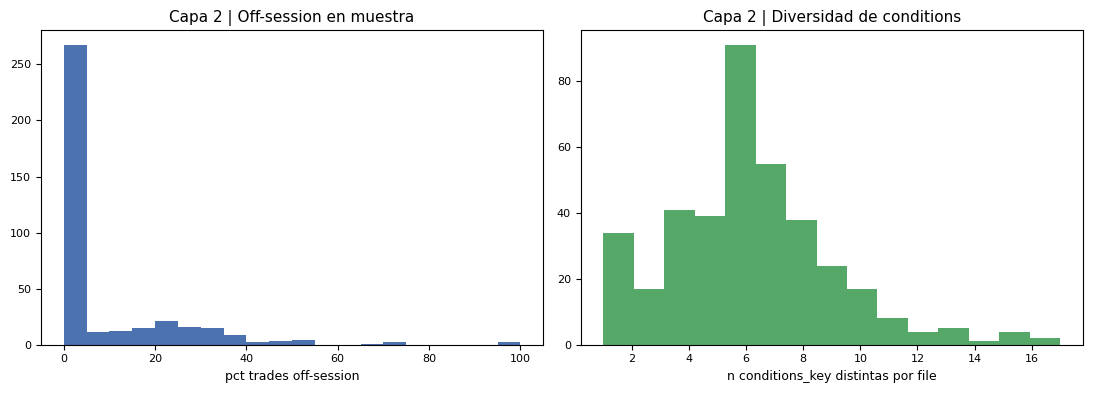

,file,m.off_session_trade_pct,off_session_trade_pct,legacy_minus_raw_off_session_pct
0,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,100.000000,0.0,100.000000
1,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,100.000000,0.0,100.000000
2,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,71.428571,0.0,71.428571
3,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,70.621469,0.0,70.621469
4,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,66.723842,0.0,66.723842
5,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,54.901961,0.0,54.901961
6,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,52.238806,0.0,52.238806
7,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,50.000000,0.0,50.000000
8,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,50.000000,0.0,50.000000
9,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,48.809524,0.0,48.809524


La segunda capa debe perfilar primero qué prints hay antes de fijar política. En `raw_file_metrics` la mediana de trades en regular sale 100.00% y la de pre/post 0.00%. La elegibilidad basal mediana queda en 100.00%.  
Pero `sample_index` marca 117 de 380 files con `off_session_trade_pct > 0`.  
La mediana entre esos casos positivos es 23.30%, así que la muestra sí contiene off-session material.  
Conclusión: esta capa sirve para observar sesión, conditions y referencias, pero la semántica de sesión en `raw_file_metrics` todavía no basta para cerrar elegibilidad final.

In [4]:
layer2 = arts['layer2_eligibility_summary']
raw_metrics = arts['raw_file_metrics']
sample_index = arts['sample_index']
layer2_session_profile = arts['layer2_session_profile']
layer2_session_mismatch = arts['layer2_session_mismatch']
layer2_profile = mod58b['build_layer2_descriptive_table'](raw_metrics, sample_index)
mod58b['display_table'](layer2, 'layer2_eligibility_summary', default_rows=20)
mod58b['display_table'](layer2_session_profile, 'layer2_session_profile', default_rows=25)
mod58b['display_table'](layer2_profile, 'layer2_profile', default_rows=20)
mod58b['plot_layer2_sessions'](raw_metrics)
mod58b['plot_layer2_observability'](raw_metrics, sample_index)
mod58b['display_table'](layer2_session_mismatch, 'layer2_session_mismatch', default_rows=20)
display(Markdown(mod58b['summary_layer2'](layer2, sample_index)))


,condition_code,trades,outside_daily_trades,outside_1m_trades,trade_pct,outside_daily_pct_within_code,outside_1m_pct_within_code
1,37,335491,127221,117269,36.079383,37.920838,34.954440
0,14,367385,149766,80245,39.509329,40.765410,21.842209
2,41,199972,80767,68162,21.505395,40.389154,34.085772
3,10,9864,4169,4176,1.060795,42.264801,42.335766
5,2,4729,2251,2699,0.508566,47.599915,57.073377
7,16,688,222,119,0.073989,32.267442,17.296512
9,32,204,91,51,0.021939,44.607843,25.000000
8,17,306,95,38,0.032908,31.045752,12.418301
10,9,178,35,24,0.019142,19.662921,13.483146
13,20,25,15,18,0.002689,60.000000,72.000000


,conditions_key,trades,outside_daily_trades,outside_1m_trades,trade_pct,outside_daily_pct_within_combo,outside_1m_pct_within_combo
0,[],536292,278321,134242,46.524491,51.897287,25.031513
1,[37],227083,93977,87072,19.699942,41.384428,38.343689
3,"[14, 41]",95563,48575,36473,8.290297,50.830342,38.166445
4,"[14, 37, 41]",94279,28233,27585,8.178907,29.946223,29.258902
2,[14],169021,70160,15420,14.662937,41.509635,9.123127
8,"[10, 2, 41]",3468,1555,2103,0.300857,44.838524,60.640138
7,"[10, 37, 41]",5338,1988,1630,0.463083,37.242413,30.535781
6,"[14, 37]",7452,2792,756,0.646477,37.466452,10.144928
9,"[10, 2]",889,548,427,0.077123,61.642295,48.031496
15,"[37, 41]",299,126,165,0.025939,42.140468,55.183946


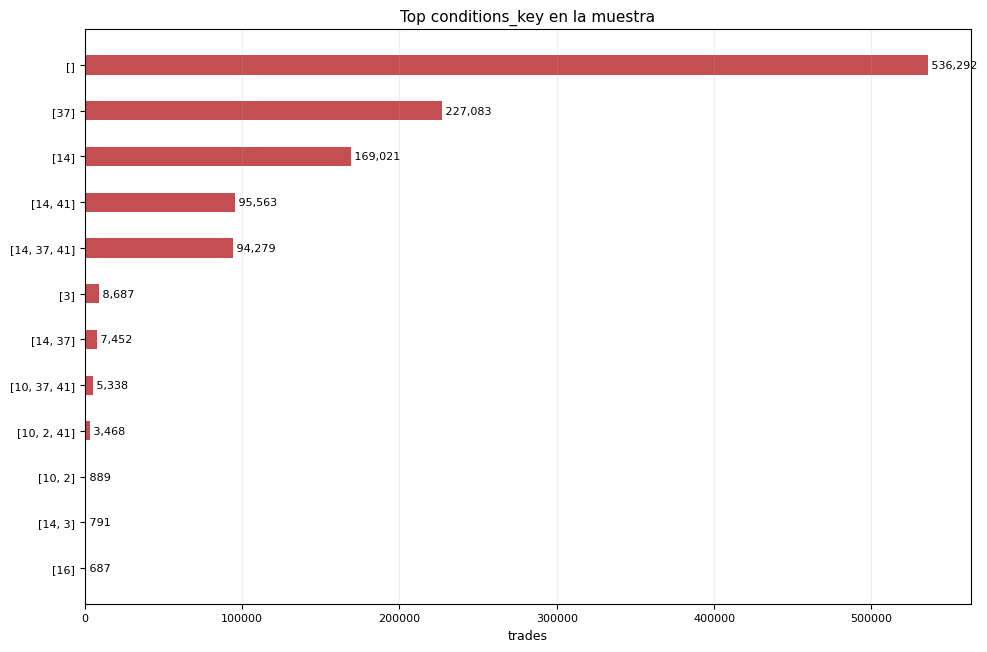

,file,ticker,date,sample_stratum,warns_list,legacy_off_session_trade_pct,has_1m_reference,has_daily_reference,warn_count,warns_joined,off_session_trade_pct,odd_lot_trade_pct,condition_combo_nunique,outside_daily_regular_pct,outside_daily_odd_lot_pct,outside_daily_round_lot_pct,outside_1m_regular_pct,outside_1m_odd_lot_pct,outside_1m_round_lot_pct,acceptance_label
13,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,KFFB,2015-12-31,SOFT_FAIL__control,"[missing_ohlcv_1m_reference, missing_ohlcv_dai...",100.000000,False,False,4,"missing_ohlcv_1m_reference, missing_ohlcv_dail...",0.0,100.000000,2,0.000000,0.000000,NaN,NaN,NaN,NaN,review
24,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,VALU,2016-02-24,HARD_FAIL__daily_range__unconfirmed__1-5,"[missing_ohlcv_1m_reference, off_session_trade...",100.000000,False,True,3,"missing_ohlcv_1m_reference, off_session_trades...",0.0,100.000000,2,100.000000,100.000000,NaN,NaN,NaN,NaN,reference_scale_mismatch
52,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,MPX,2014-01-28,HARD_FAIL__daily_range__confirmed__0.10-0.25,"[duplicate_excess_ratio_gt_threshold, off_sess...",71.428571,True,True,3,"duplicate_excess_ratio_gt_threshold, off_sessi...",0.0,36.813187,6,1.648352,4.477612,0.0,4.878049,14.285714,0.869565,review
226,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,FGBI,2023-01-26,HARD_FAIL__daily_range__confirmed__0.50-1,"[duplicate_exact_trade_rows_present, off_sessi...",70.621469,True,True,3,"duplicate_exact_trade_rows_present, off_sessio...",0.0,97.740113,6,15.819209,16.184971,0.0,85.714286,92.307692,0.000000,reference_scale_mismatch
258,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,LEXX,2026-03-06,HARD_FAIL__daily_range__confirmed__<=0.01,"[duplicate_exact_trade_rows_present, off_sessi...",66.723842,True,True,3,"duplicate_exact_trade_rows_present, off_sessio...",0.0,44.425386,8,1.715266,3.861004,0.0,7.157895,22.516556,0.000000,review
329,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,FBIZ,2023-02-02,HARD_FAIL__daily_range__unconfirmed__0.25-0.50,"[duplicate_exact_trade_rows_present, off_sessi...",54.901961,True,True,2,"duplicate_exact_trade_rows_present, off_sessio...",0.0,85.539216,6,1.715686,2.005731,0.0,35.114504,45.320197,0.000000,review_microstructure
184,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,GMM,2011-12-16,HARD_FAIL__daily_range__confirmed__>5,"[duplicate_excess_ratio_gt_threshold, off_sess...",52.238806,True,True,3,"duplicate_excess_ratio_gt_threshold, off_sessi...",0.0,0.000000,3,100.000000,NaN,100.0,100.000000,NaN,100.000000,reference_scale_mismatch
217,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,TCBS,2022-02-02,HARD_FAIL__daily_range__confirmed__0.25-0.50,"[off_session_trades_present, trade_price_outsi...",50.000000,True,True,2,"off_session_trades_present, trade_price_outsid...",0.0,73.529412,6,14.705882,20.000000,0.0,7.142857,20.000000,0.000000,review_microstructure
315,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,OFED,2017-12-20,HARD_FAIL__daily_range__unconfirmed__0.50-1,"[missing_ohlcv_1m_reference, off_session_trade...",50.000000,False,True,2,"missing_ohlcv_1m_reference, off_session_trades...",0.0,100.000000,4,100.000000,100.000000,NaN,NaN,NaN,NaN,review_no_1m_reference
298,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,POCI,2023-02-14,HARD_FAIL__daily_range__unconfirmed__0.10-0.25,"[duplicate_exact_trade_rows_present, off_sessi...",48.809524,True,True,2,"duplicate_exact_trade_rows_present, off_sessio...",0.0,86.904762,5,48.809524,56.164384,0.0,18.750000,60.000000,0.000000,review_microstructure


In [5]:
condition_code_summary = arts['condition_code_summary']
condition_combo_summary = arts['condition_combo_summary']
layer2_case_view = mod58b['build_layer2_case_view'](sample_index, raw_metrics)
mod58b['display_table'](condition_code_summary.sort_values(['outside_1m_trades','trades'], ascending=[False, False]), 'condition_code_summary', default_rows=20)
mod58b['display_table'](condition_combo_summary.sort_values(['outside_1m_trades','trades'], ascending=[False, False]), 'condition_combo_summary', default_rows=20)
mod58b['plot_layer2_condition_combos'](condition_combo_summary, top_n=12)
mod58b['display_table'](layer2_case_view.sort_values(
    ['legacy_off_session_trade_pct','off_session_trade_pct','outside_1m_odd_lot_pct','warn_count'], 
    ascending=[False, False, False, False]), 
    'layer2_case_view', 
    default_rows=10
    )


Resumen breve de hallazgos de la segunda capa: aqu? no cerramos todav?a la pol?tica. Primero perfilamos la muestra y comprobamos si sesi?n, `conditions` y referencias est?n bien observadas. Si `sample_index` y `raw_file_metrics` se contradicen en off-session, esa discrepancia hay que resolverla antes de usar esta capa como criterio final.

## Tercera capa

**Calidad interna del tape**. Incluso con referencias sanas, un tape duplicado o con bursts artificiales contamina el diagn?stico.

,metric,value
0,median_duplicate_exact_ratio_pct_raw,0.000000
1,p95_duplicate_exact_ratio_pct_raw,20.315517
2,median_max_trades_same_timestamp_raw,2.000000
3,median_condition_combo_nunique,6.000000


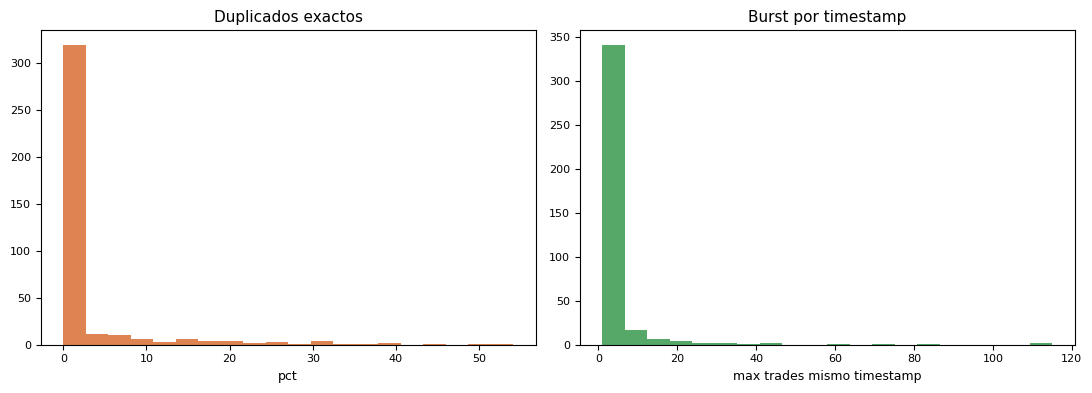

La tercera capa mide suciedad mecánica del tape. La mediana de duplicado exacto es 0.00% y el p95 sube a 20.32%. El burst mediano por timestamp es 2.00. Esto separa files limpios de files contaminados por repetición artificial.

In [6]:
layer3 = arts['layer3_tape_quality_summary']
mod58b['display_table'](layer3, 'layer3_tape_quality_summary', default_rows=20)
mod58b['plot_layer3_quality'](raw_metrics)
display(Markdown(mod58b['summary_layer3'](layer3)))


In [7]:
quality_view = raw_metrics[['file','ticker','date','duplicate_exact_ratio_pct_raw','max_trades_same_timestamp_raw','condition_combo_nunique','sample_stratum']].copy()
mod58b['display_table'](quality_view.sort_values(['duplicate_exact_ratio_pct_raw','max_trades_same_timestamp_raw'], ascending=[False, False]), 'quality_view', default_rows=20)


,file,ticker,date,duplicate_exact_ratio_pct_raw,max_trades_same_timestamp_raw,condition_combo_nunique,sample_stratum
168,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,YHOO,2007-09-27,54.091191,75,12,HARD_FAIL__control
342,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2008-10-20,50.078882,111,7,HARD_FAIL__daily_range__unconfirmed__>5
176,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,CAL,2008-11-19,43.467553,23,7,HARD_FAIL__control
188,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,COMS,2005-08-11,39.308981,115,4,HARD_FAIL__daily_range__confirmed__>5
274,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,BBBY,2007-11-30,38.800040,32,11,HARD_FAIL__daily_range__confirmed__1-5
167,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XL,2012-01-20,36.457787,32,8,HARD_FAIL__control
92,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,ADXS,2025-06-18,33.333333,2,2,HARD_FAIL__daily_range__confirmed__0.05-0.10
353,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2008-04-30,32.222371,58,10,HARD_FAIL__daily_range__unconfirmed__>5
354,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2011-05-18,31.501243,22,8,HARD_FAIL__daily_range__unconfirmed__>5
331,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,ZIOP,2015-06-19,31.042087,42,11,HARD_FAIL__daily_range__unconfirmed__0.25-0.50


Resumen breve de hallazgos de la tercera capa: aqu? distinguimos un problema econ?mico real de un problema de tape sucio. Si duplicados y bursts dominan, la lectura de breaks pierde fiabilidad.

## Cuarta capa

**Consistencia contra referencias**. Ya no basta con saber si existe un extremo fuera; ahora medimos masa real del outside contra `daily` y `1m`.

,metric,value
0,median_outside_daily_pct,3.117716
1,median_outside_daily_regular_pct,3.117716
2,median_outside_daily_volume_pct,0.263122
3,median_outside_1m_pct,11.640646
4,median_outside_1m_regular_pct,11.640646
5,median_trade_vwap_vs_daily_vw_diff_pct_raw,0.124787


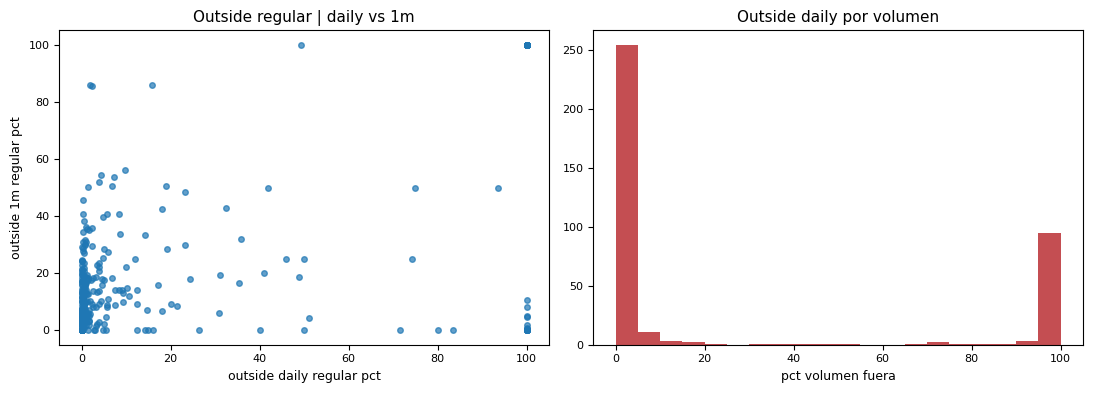

La cuarta capa ya mide si el flujo elegible rompe de verdad contra referencias. La mediana de outside regular contra daily es 3.12%, contra 1m es 11.64%, y el outside por volumen mediano es 0.26%. Aquí deja de importar un solo min/max y empieza a importar la masa real del desvío.

In [8]:
layer4 = arts['layer4_reference_consistency_summary']
mod58b['display_table'](layer4, 'layer4_reference_consistency_summary', default_rows=20)
mod58b['plot_layer4_consistency'](raw_metrics)
display(Markdown(mod58b['summary_layer4'](layer4)))


In [9]:
reference_view = raw_metrics[['file','ticker','date','outside_daily_pct','outside_daily_regular_pct','outside_daily_volume_pct','outside_1m_pct','outside_1m_regular_pct','sample_stratum']].copy()
mod58b['display_table'](reference_view.sort_values(['outside_daily_regular_pct','outside_1m_regular_pct'], ascending=[False, False]), 'reference_view', default_rows=20)


,file,ticker,date,outside_daily_pct,outside_daily_regular_pct,outside_daily_volume_pct,outside_1m_pct,outside_1m_regular_pct,sample_stratum
6,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,NEON,2014-02-25,100.0,100.0,100.0,100.0,100.0,SOFT_FAIL__control
29,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,CPHI,2024-09-04,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__unconfirmed__1-5
164,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,WMC,2012-06-11,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__control
177,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,TISI,2009-09-29,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__control
178,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,ANGI,2012-11-29,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__control
180,D:\trades_ticks_prod_2005_2026\DRMA\year=2023\...,DRMA,2023-04-26,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__confirmed__>5
181,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,AHT,2019-12-11,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__confirmed__>5
182,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,OCX,2022-09-13,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__confirmed__>5
183,D:\trades_ticks_prod_2005_2026\CLRO\year=2023\...,CLRO,2023-07-21,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__confirmed__>5
184,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,GMM,2011-12-16,100.0,100.0,100.0,100.0,100.0,HARD_FAIL__daily_range__confirmed__>5


Resumen breve de hallazgos de la cuarta capa: aqu? queda claro si el file solo roza el borde o si una fracci?n material del flujo elegible rompe de verdad las referencias.

## Quinta capa

**M?tricas de severidad real**. Esta capa separa spike puntual de problema persistente: cu?nto outside hay, cu?nto dura y cu?n concentrado est?.

,metric,value
0,median_outside_minutes_pct_active,5.263158
1,median_longest_outside_run_minutes,1.000000
2,median_top_outside_minute_trade_share_pct,40.000000
3,median_top_outside_minute_volume_share_pct,62.893082
4,median_outside_daily_prepost_pct,NaN


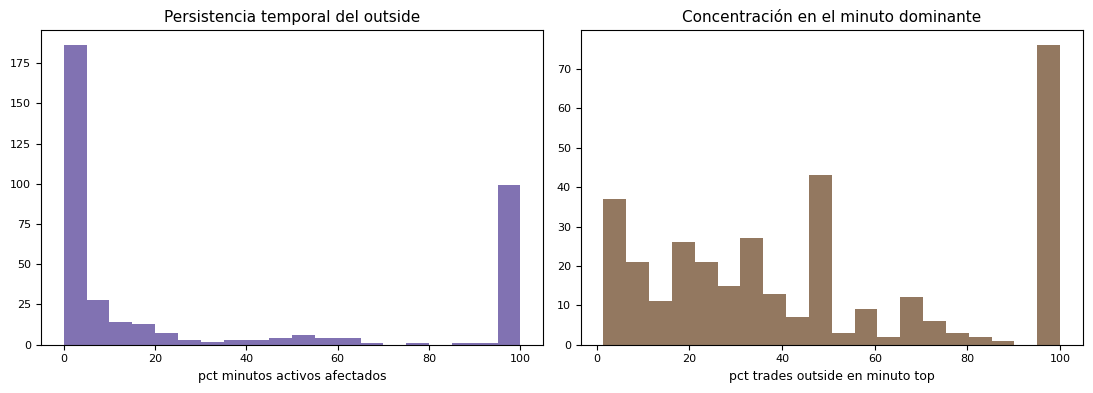

La quinta capa distingue spike puntual frente a problema persistente. La mediana del outside afecta al 5.26% de minutos activos, la racha máxima mediana es 1.00 minutos y el minuto dominante concentra 40.00% de los trades outside.

In [10]:
layer5 = arts['layer5_severity_real_summary']
mod58b['display_table'](layer5, 'layer5_severity_real_summary', default_rows=20)
mod58b['plot_layer5_severity'](raw_metrics)
display(Markdown(mod58b['summary_layer5'](layer5)))


In [11]:
severity_view = raw_metrics[['file','ticker','date','outside_minutes_pct_active','longest_outside_run_minutes','top_outside_minute_trade_share_pct','top_outside_minute_volume_share_pct','outside_daily_prepost_pct','sample_stratum']].copy()
mod58b['display_table'](severity_view.sort_values(['outside_minutes_pct_active','longest_outside_run_minutes'], ascending=[False, False]), 'severity_view', default_rows=20)


,file,ticker,date,outside_minutes_pct_active,longest_outside_run_minutes,top_outside_minute_trade_share_pct,top_outside_minute_volume_share_pct,outside_daily_prepost_pct,sample_stratum
21,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2023-05-26,100.0,390,2.927997,3.332289,NaN,HARD_FAIL__daily_range__unconfirmed__1-5
26,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2024-10-28,100.0,390,3.057607,4.892986,NaN,HARD_FAIL__daily_range__unconfirmed__1-5
38,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2025-08-22,100.0,390,2.241093,2.683393,NaN,HARD_FAIL__daily_range__unconfirmed__1-5
239,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,BBBY,2019-08-19,100.0,390,3.115475,4.832192,NaN,HARD_FAIL__daily_range__confirmed__0.50-1
274,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,BBBY,2007-11-30,100.0,390,1.445316,4.916821,NaN,HARD_FAIL__daily_range__confirmed__1-5
343,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,FCEL,2020-08-26,100.0,390,1.492201,2.288000,NaN,HARD_FAIL__daily_range__unconfirmed__>5
351,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2014-05-21,100.0,390,2.843785,4.546056,NaN,HARD_FAIL__daily_range__unconfirmed__>5
353,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2008-04-30,100.0,390,1.770386,2.699424,NaN,HARD_FAIL__daily_range__unconfirmed__>5
354,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2011-05-18,100.0,390,3.144005,8.140639,NaN,HARD_FAIL__daily_range__unconfirmed__>5
357,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,XRX,2016-03-01,100.0,390,2.712689,4.490868,NaN,HARD_FAIL__daily_range__unconfirmed__>5


Resumen breve de hallazgos de la quinta capa: cuanto m?s persistente y m?s repartido est? el outside, menos defendible ser? como micro-outlier inocuo.

## Sexta capa

**Criterio expl?cito de aceptaci?n**. Toda la l?gica anterior termina aqu?, pero ya no en un eje simple `good/review/bad`. La pol?tica actual separa `good`, `review`, `review_microstructure`, `review_no_1m_reference`, `reference_scale_mismatch` y `bad_data`.

,acceptance_label,files,median_outside_daily_regular_pct,median_outside_daily_regular_volume_pct,median_outside_1m_regular_pct,median_outside_minutes_pct_active,median_trade_vwap_vs_daily_vw_diff_pct_raw
0,review,140,0.107864,0.006664,4.925054,0.516130,0.041614
1,review_microstructure,111,1.515152,0.294298,18.181818,3.508772,0.091415
2,reference_scale_mismatch,106,100.000000,100.000000,85.714286,100.000000,43.058712
3,review_no_1m_reference,21,100.000000,100.000000,NaN,100.000000,0.542067
4,review_1m_reference_alignment,2,2.051140,3.000416,85.754476,1.638766,1.873832


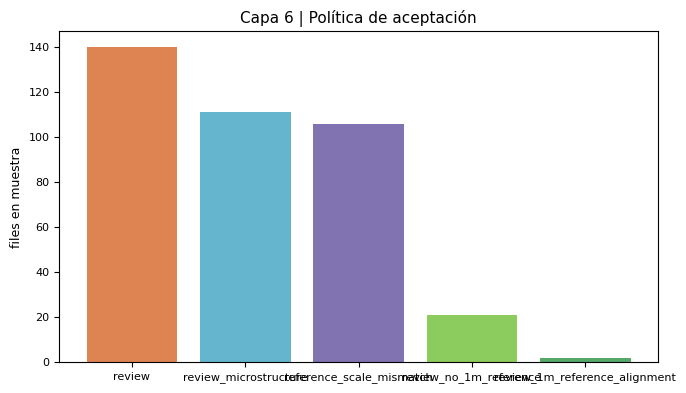

La sexta capa convierte métricas en decisión operativa separando `bad_data`, `reference_scale_mismatch` y los bloques de comparabilidad de referencia. El reparto actual de la muestra es: review=140, review_microstructure=111, reference_scale_mismatch=106, review_no_1m_reference=21, review_1m_reference_alignment=2.

In [12]:
layer6 = arts['layer6_policy_summary']
policy_examples = arts['layer6_policy_examples']
mod58b['display_table'](layer6, 'layer6_policy_summary', default_rows=20)
mod58b['plot_layer6_policy'](layer6)
display(Markdown(mod58b['summary_layer6'](layer6)))


In [13]:
policy_view = policy_examples[['acceptance_label','file','ticker','date','scale_bucket_vw','scale_bucket_high','trade_vwap_vs_daily_vw_diff_pct_raw','outside_daily_regular_pct','outside_daily_regular_volume_pct','outside_1m_regular_pct','outside_minutes_pct_active','duplicate_exact_ratio_pct_raw','sample_stratum']].copy()
mod58b['display_table'](policy_view, 'policy_view', default_rows=30)


,acceptance_label,file,ticker,date,scale_bucket_vw,scale_bucket_high,trade_vwap_vs_daily_vw_diff_pct_raw,outside_daily_regular_pct,outside_daily_regular_volume_pct,outside_1m_regular_pct,outside_minutes_pct_active,duplicate_exact_ratio_pct_raw,sample_stratum
0,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,NEON,2014-02-25,~10x,~10x,89.999762,100.0,100.0,100.0,100.0,15.639985,SOFT_FAIL__control
1,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,CPHI,2024-09-04,near_10x,~10x,90.609229,100.0,100.0,100.0,100.0,0.787402,HARD_FAIL__daily_range__unconfirmed__1-5
2,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,WMC,2012-06-11,~10x,~10x,89.998518,100.0,100.0,100.0,100.0,17.485549,HARD_FAIL__control
3,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,TISI,2009-09-29,~10x,~10x,89.996430,100.0,100.0,100.0,100.0,7.280514,HARD_FAIL__control
4,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,ANGI,2012-11-29,~10x,~10x,90.009587,100.0,100.0,100.0,100.0,23.859489,HARD_FAIL__control
5,reference_scale_mismatch,D:\trades_ticks_prod_2005_2026\DRMA\year=2023\...,DRMA,2023-04-26,~150x,~150x,99.330720,100.0,100.0,100.0,100.0,0.220507,HARD_FAIL__daily_range__confirmed__>5
6,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,AHT,2019-12-11,~1000x,~1000x,99.900006,100.0,100.0,100.0,100.0,0.471846,HARD_FAIL__daily_range__confirmed__>5
7,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,OCX,2022-09-13,~20x,~20x,95.009539,100.0,100.0,100.0,100.0,0.833333,HARD_FAIL__daily_range__confirmed__>5
8,reference_scale_mismatch,D:\trades_ticks_prod_2005_2026\CLRO\year=2023\...,CLRO,2023-07-21,~15x,~15x,93.322926,100.0,100.0,100.0,100.0,0.000000,HARD_FAIL__daily_range__confirmed__>5
9,reference_scale_mismatch,C:\TSIS_Data\data\trades_ticks_prod_2005_2026\...,GMM,2011-12-16,~15x,~15x,93.333625,100.0,100.0,100.0,100.0,5.970149,HARD_FAIL__daily_range__confirmed__>5


Resumen breve de hallazgos de la sexta capa: esta capa ya separa una parte relevante del residuo como `reference_scale_mismatch`, otra como `review_microstructure` y otra como `review_no_1m_reference`, en lugar de mezclarlo todo con `bad_data`. El siguiente paso ya no es discutir un caso a ojo, sino revisar si la nueva frontera entre esas familias est? calibrada de forma razonable.

## Cierre

La lectura actual de este notebook ya no apunta primero a `bad trades data`. Apunta a tres cosas m?s concretas: m?tricos heredados de sesi?n poco fiables, conflicto concentrado en odd-lots y un residuo extremo dominado por `reference_scale_mismatch` frente a `daily` y `1m`.  
  
La pol?tica actual ya refleja esa separaci?n: `review=164`, `reference_scale_mismatch=106`, `review_microstructure=66`, `review_no_1m_reference=21`, `bad_data=12`, `good=11`.  
  
Por tanto, el siguiente paso correcto no es endurecer sin m?s la etiqueta `bad`, sino seguir reduciendo `bad_data` hacia causas explicables y reservar esa etiqueta para el residuo realmente atribuible al tape o al file.